<a href="https://colab.research.google.com/github/Tuchobm/Curso-IA-Google-Colab/blob/main/4_1_cnn_result.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio 1: Entrenamiento de redes neuronales

En este ejercicio entrenarás un modelo de redes neuronales ([restnet-18](https://arxiv.org/pdf/1512.03385)) buscando los mejores hiperparámetros. Completa las secciones indicadas y analiza los resultados obtenidos para evaluar la eficiencia de cada método.

Además, encontrarás partes del código contendrán el comentario de '# ACTIVIDAD' que indican dónde debes completar el código o realizar tareas específicas. Asegúrate de seguir las instrucciones y completar el código donde se indique. Finalmente, en el final de este ejercicio, deberás responder a una serie de preguntas.

In [ ]:
import torch
import numpy as np

# Aseguramos que los resultados sean reproducibles
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed(0)
torch.backends.cudnn.deterministic = True

## Cargamos dataset

In [ ]:
import torch
from torchvision import datasets, transforms

transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,)),
    ]
)

data = datasets.CIFAR100(
    root="data",
    train=False,
    download=True,
    transform=transform,
)

# Dividir el conjunto de datos en 3 partes
train, validation, test = torch.utils.data.random_split(data, [0.8, 0.1, 0.1])

100%|██████████| 169M/169M [00:13<00:00, 12.6MB/s]


In [ ]:
print(f"Tamaño del conjunto de entrenamiento: {len(train)}")
print(f"Tamaño del conjunto de validación: {len(validation)}")
print(f"Tamaño del conjunto de prueba: {len(test)}")

Tamaño del conjunto de entrenamiento: 8000
Tamaño del conjunto de validación: 1000
Tamaño del conjunto de prueba: 1000


## Creación del modelo

In [ ]:
from torchvision import models
import torch.nn as nn

model = models.resnet18()
# Modificar el modelo para aceptar 100 clases
model.fc = nn.Linear(model.fc.in_features, 100)

## Entrenar el modelo

In [ ]:
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt


def train_model(
    model, train_loader, val_loader, optimizer, criterion=None, device="cpu", epochs=5
):
    """
    Entrenar un modelo con seguimiento de progreso y métricas de precisión.

    Args:
        model: Modelo PyTorch para entrenar
        train_loader: DataLoader para datos de entrenamiento
        val_loader: DataLoader para datos de validación
        optimizer: Optimizador PyTorch
        criterion: Función de loss (por defecto CrossEntropyLoss)
        device: Dispositivo a utilizar ('cpu' o 'cuda')
        epochs: Número de épocas de entrenamiento

    Returns:
        dict: Historial de entrenamiento con métricas
    """
    model.to(device)
    if criterion is None:
        criterion = torch.nn.CrossEntropyLoss()

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    # Barra de progreso de épocas
    epoch_pbar = tqdm(range(epochs), desc="Épocas")
    for epoch in epoch_pbar:
        # Fase de entrenamiento
        model.train()
        train_loss = 0.0
        correct = 0
        total = 0

        # Barra de progreso de lotes
        batch_pbar = tqdm(train_loader, desc="Entrenamiento", leave=False)
        for images, labels in batch_pbar:
            images = images.to(device)
            labels = labels.to(device)

            # Paso forward + backward + optimización
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Calcular exactitud
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # Paso hacia atrás y optimización
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Actualizar historial de métricas
            train_loss += loss.item()
            rolling_acc = 100 * correct / total

            batch_pbar.set_postfix(
                {"loss": f"{loss.item():.4f}", "acc": f"{rolling_acc:.2f}%"}
            )

        # Calcular métricas de época
        epoch_train_loss = train_loss / len(train_loader)
        epoch_train_acc = 100 * correct / total
        history["train_loss"].append(epoch_train_loss)
        history["train_acc"].append(epoch_train_acc)

        # Fase de validación
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        val_pbar = tqdm(val_loader, desc="Validación", leave=False)
        for images, labels in val_pbar:
            images = images.to(device)
            labels = labels.to(device)

            with torch.no_grad():
                outputs = model(images)
                loss = criterion(outputs, labels)

            # Calcular exactitud
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # Actualizar historial de métricas
            val_loss += loss.item()

            # Actualizar barra de progreso
            val_pbar.set_postfix({"loss": f"{loss.item():.4f}"})

        # Calcular métricas de validación
        epoch_val_loss = val_loss / len(val_loader)
        epoch_val_acc = 100 * correct / total
        history["val_loss"].append(epoch_val_loss)
        history["val_acc"].append(epoch_val_acc)

        # Actualizar barra de progreso de época
        epoch_pbar.set_postfix(
            {
                "train_loss": f"{epoch_train_loss:.4f}",
                "train_acc": f"{epoch_train_acc:.2f}%",
                "val_loss": f"{epoch_val_loss:.4f}",
                "val_acc": f"{epoch_val_acc:.2f}%",
            }
        )

    return history

In [ ]:
# ACTIVIDAD: Prueba el modelo con diferentes hiperparámetros
epochs = 5
batch_size = 64

lr = 0.1
betas = (0.5, 0.9)
eps = 1e-08
weight_decay = 0.0

train_loader = torch.utils.data.DataLoader(
    train, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True
)

validation_loader = torch.utils.data.DataLoader(
    validation, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=lr,
    betas=betas,
    eps=eps,
    weight_decay=weight_decay,
)

critirion = torch.nn.CrossEntropyLoss()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

history = train_model(
    model,
    train_loader,
    validation_loader,
    optimizer,
    criterion=critirion,
    device=device,
    epochs=epochs,
)

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Épocas:   0%|          | 0/5 [00:00<?, ?it/s]

Entrenamiento:   0%|          | 0/125 [00:00<?, ?it/s]

Validación:   0%|          | 0/16 [00:00<?, ?it/s]

Entrenamiento:   0%|          | 0/125 [00:00<?, ?it/s]

...

Validación:   0%|          | 0/16 [00:00<?, ?it/s]

Entrenamiento:   0%|          | 0/125 [00:00<?, ?it/s]

Validación:   0%|          | 0/16 [00:00<?, ?it/s]

Entrenamiento:   0%|          | 0/125 [00:00<?, ?it/s]

Validación:   0%|          | 0/16 [00:00<?, ?it/s]

## Visualizar progresión del entrenamiento

In [ ]:
def plot_history(history):
    """
    Visualizar el historial de entrenamiento y validación.

    Args:
        history: Diccionario que contiene el historial de entrenamiento
    """
    # Visualizar la pérdida y precisión de entrenamiento y validación
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    ax[0].plot(history["train_loss"], label="Entrenamiento")
    ax[0].plot(history["val_loss"], label="Validación")
    ax[0].set_title("Pérdida")
    ax[0].set_xlabel("Épocas")
    ax[0].set_ylabel("Pérdida")
    ax[0].legend()

    # ACTIVIDAD: Visualizar la precisión de entrenamiento y validación
    ax[1].plot(history["train_acc"], label="Entrenamiento")
    ax[1].plot(history["val_acc"], label="Validación")
    ax[1].set_title("Accurcy")
    ax[1].set_xlabel("Épocas")
    ax[1].set_ylabel("Accuracy")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

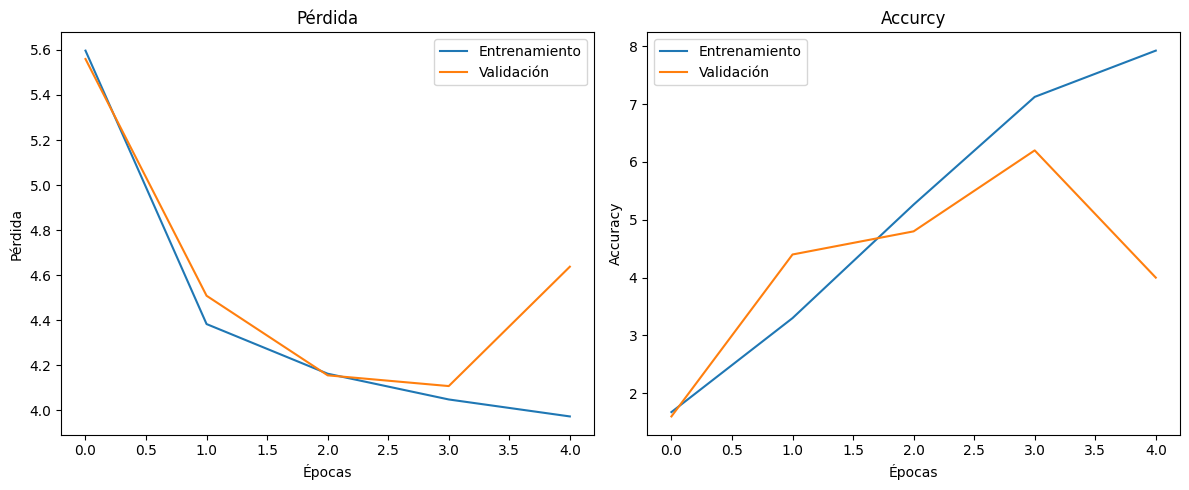

In [ ]:
plot_history(history)

## Evaluar el modelo

In [ ]:
def predict_model(model, test_loader, device="cpu"):
    """
    Predecir etiquetas para un conjunto de datos utilizando un modelo entrenado.

    Args:
        model: Modelo PyTorch para evaluar
        test_loader: DataLoader para datos de prueba
        device: Dispositivo a utilizar ('cpu' o 'cuda')

    Returns:
        list: Lista de etiquetas predichas
        list: Lista de etiquetas verdaderas
    """
    model.eval()
    all_predictions = []
    truth_labels = []

    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        with torch.no_grad():
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            all_predictions.extend(predicted.cpu().numpy())
            truth_labels.extend(labels.cpu().numpy())

    return all_predictions, truth_labels

In [ ]:
from sklearn.metrics import accuracy_score

# ACTIVIDAD: Evaluar el modelo en el conjunto de prueba
test_loader = torch.utils.data.DataLoader(
    test, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True
)
predictions, truth_labels = predict_model(model, test_loader, device=device)
accuracy = accuracy_score(truth_labels, predictions)
print(f"Precisión en el conjunto de prueba: {accuracy * 100:.2f}%")

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Precisión en el conjunto de prueba: 4.50%


- ¿Cuáles han sido los mejores hiperparámetros que has encontrado? Prueba por lo menos las siguientes combinaciones y otros 5 más:
  - epochs=5, lr=0.001, betas=(0.9, 0.999), eps=1e-08
  - epochs=10, lr=0.001, betas=(0.9, 0.999), eps=1e-08
  - epochs=5, lr=0.01, betas=(0.9, 0.999), eps=1e-08
  - epochs=10, lr=0.01, betas=(0.5, 0.9), eps=1e-08
  - epochs=5, lr=0.1, betas=(0.5, 0.9), eps=1e-08

  * Resultados en orden: 13.70%, 25.00%, 9.90%, 19.80%, 5.10%
- ¿Qué pasa si el learning rate es muy alto o muy bajo? (Probad con varios valores 0.0001, 0.001, 0.01, 0.1)
  * Si el learning rate es muy alto el modelo no converge y si es muy bajo tarda mucho en converger
- ¿Cuánto tiempo tarda en entrenar el modelo usando CPU y GPU?
  * GPU es más o menos 10 a 20 veces más rápido
- ¿Qué accuracy tiene el modelo si solo lo entrenas una época?
  * Depende de los hiperparámetros, pero en general es muy bajo (menos de 10%)
- ¿Cómo evoluciona el accuracy si lo entrenamos 10 épocas? ¿Crece más rápido al principio o al final?
  * Depende de los hiperparámetros, pero en general crece más rápido al principio y luego se estabiliza. Si no es el caso, el modelo aún puede entrenarse mucho más.
- ¿Si entrenamos el modelo por mucho tiempo, que pasa? (Probad con 100 épocas si tenéis tiempo y GPU)
  * El modelo se sobre entrena y el accuracy en el test puede ser peor que en épocas anteriores.